<a href="https://colab.research.google.com/github/maalaaikaa/Intro-to-Computer-Vision/blob/main/Lab_4_Assignment_No_1/Skin_Lesion_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Assignment: Skin Lesion Boundary Detection Using Canny
## Solution
**Objective:** determine how well filtering and edge detection can separate a skin lesion from surrounding skin.

**Dataset:** `nodoubttome/skin-cancer9-classesisic`, using the teacher-provided KaggleHub setup and four classes: melanoma, pigmented benign keratosis, basal cell carcinoma and nevus.

**How to run:** open this notebook in Jupyter or Google Colab and select **Run All**. No code changes, manual image uploads, GPU or training are needed. The first run downloads approximately 786 MB, then processes only five images. Internet is required for the first download and any missing packages. Allow disk space for the extracted dataset as well.

All six tasks, five processing sequences, the five-image results table, the eight-method comparison table and all six answers are included. Results are saved to `kaggle_lab_outputs`. The notebook contains outputs from a completed run on this dataset.

**Scope:** this is an image-processing lab. Areas and perimeters are approximate image-pixel measurements, not clinical measurements. Detection failures are part of the results and are explained rather than hidden.

In [8]:
# Install only missing packages.
import importlib.util
import subprocess
import sys
packages = {"kagglehub": "kagglehub", "cv2": "opencv-python", "numpy": "numpy",
            "matplotlib": "matplotlib", "pandas": "pandas"}
missing = [package for module, package in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
print("Packages ready.")

Packages ready.


In [9]:
import os
from pathlib import Path
import kagglehub

# Same dataset and folders as Lab 01 and Lab 02.
dataset_path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
DATASET_ROOT = os.path.join(dataset_path, "Skin cancer ISIC The International Skin Imaging Collaboration")
TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
SELECTED_CLASSES = [
    "melanoma",
    "pigmented benign keratosis",
    "basal cell carcinoma",
    "nevus"
]

# Handle an extra enclosing folder if the downloaded layout changes.
if not Path(TRAIN_DIR).is_dir():
    train_folders = [p for p in Path(dataset_path).rglob("Train")
                     if all((p / name).is_dir() for name in SELECTED_CLASSES)]
    if len(train_folders) != 1:
        raise FileNotFoundError("Could not locate the Train folder containing the four classes.")
    TRAIN_DIR = str(train_folders[0])
print("Dataset loaded successfully.")
print("Train folder:", TRAIN_DIR)

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Dataset loaded successfully.
Train folder: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train


## Image selection and settings
Five fixed training images are used so the figures, measurements and written observations correspond to the same inputs on every run. There is one image from each selected class and a second melanoma image. This small illustrative selection is not an accuracy benchmark.

The three example threshold pairs are tested exactly: **50–100, 100–200 and 150–250**. An additional **20–40** setting is included because the three example pairs largely miss the faint lesion margins. Visual comparison of these five images supports 20–40 as the most informative of the tested settings overall; none gives a complete reliable outline for every image. Gaussian is the selected main-pipeline filter because it reduces fine texture while retaining more faint-edge information than the stronger averaging filter.

Parameters and observations are already set for these five images; no edits are required.

In [10]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

OUTPUT_FOLDER = Path("kaggle_lab_outputs")
OUTPUT_FOLDER.mkdir(exist_ok=True)
MAX_SIDE = 512
THRESHOLDS = [(50, 100), (100, 200), (150, 250), (20, 40)]
BEST_THRESHOLD = (20, 40)
BEST_FILTER = "Gaussian"

SELECTED_IMAGES = [
    ("melanoma", "ISIC_0000139.jpg"),
    ("pigmented benign keratosis", "ISIC_0024435.jpg"),
    ("basal cell carcinoma", "ISIC_0024504.jpg"),
    ("nevus", "ISIC_0000019.jpg"),
    ("melanoma", "ISIC_0000141.jpg")
]
paths = [Path(TRAIN_DIR) / class_name / filename
         for class_name, filename in SELECTED_IMAGES]
for index, path in enumerate(paths, start=1):
    if not path.is_file():
        raise FileNotFoundError(f"Expected dataset image is missing: {path}")
    print(f"Image {index}: {path.parent.name} / {path.name}")

Image 1: melanoma / ISIC_0000139.jpg
Image 2: pigmented benign keratosis / ISIC_0024435.jpg
Image 3: basal cell carcinoma / ISIC_0024504.jpg
Image 4: nevus / ISIC_0000019.jpg
Image 5: melanoma / ISIC_0000141.jpg


## Helper functions explained
- `show_images`: displays and saves labelled figures.
- `largest_contour`: finds external contours, rejects very small regions and contours touching the frame, then selects the largest remaining candidate.
- `find_boundary`: closes gaps in the Canny map with a 5 × 5 kernel for two iterations. If no eligible enclosed contour remains, it tries inverse Otsu thresholding of the Gaussian image, followed by opening and closing. The table explicitly identifies this **thresholding fallback**; it is not a Canny-only result.
- `sobel_edges`: calculates horizontal and vertical gradients, combines their magnitudes, normalizes them and uses Otsu to display a binary Sobel map.

Contour selection assumes one main lesion and can still select the wrong region. A filled contour gives the area; its closed arc length gives the perimeter. Area includes the boundary pixels. Measurements refer to the resized image, with its longest side at 512 pixels and aspect ratio preserved.

In [11]:
def show_images(images, titles, filename, columns=None):
    columns = columns or len(images)
    rows = int(np.ceil(len(images) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(3.3 * columns, 3 * rows), squeeze=False)
    for ax, image, title in zip(axes.flat, images, titles):
        ax.imshow(image, cmap="gray" if image.ndim == 2 else None)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    for ax in list(axes.flat)[len(images):]:
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(OUTPUT_FOLDER / filename, dpi=130, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def largest_contour(binary):
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    h, w = binary.shape
    candidates = []
    for contour in contours:
        x, y, cw, ch = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        if 0.01 * h * w < area < 0.85 * h * w and x > 2 and y > 2 and x + cw < w - 2 and y + ch < h - 2:
            candidates.append(contour)
    return max(candidates, key=cv2.contourArea) if candidates else None


def find_boundary(edges, blurred):
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
    contour = largest_contour(closed)
    method = "Canny + closing + contour"
    if contour is None:
        _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
        contour = largest_contour(binary)
        method = "Otsu fallback + contour"
    mask = np.zeros_like(edges)
    if contour is None:
        return None, mask, np.nan, np.nan, "No usable boundary"
    cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
    area = int(cv2.countNonZero(mask))
    perimeter = round(cv2.arcLength(contour, True), 2)
    return contour, mask, area, perimeter, method


def sobel_edges(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = cv2.magnitude(gx, gy)
    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, edges = cv2.threshold(magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return edges

## Tasks 1 to 6 and the required visualization
The following short loop completes all six tasks for each image:

1. **Load the image:** display its RGB original, resized for consistent processing.
2. **Preprocess:** create grayscale and Gaussian-filtered versions.
3. **Apply Canny:** display all three required threshold maps and the extra low-threshold map.
4. **Select a result:** use 20–40, based on the visual comparison and explanations below.
5. **Detect the boundary:** close edge gaps and select an eligible contour, using the labelled thresholding fallback when needed; draw it in green.
6. **Calculate area and perimeter:** fill the contour, count pixels and calculate its length.

Each five-panel figure follows **Original → Grayscale → Gaussian Filter → Canny → Lesion Boundary**. The next section explains each result, including unreliable estimates.

Image 1: ISIC_0000139.jpg, processed size 512 x 384


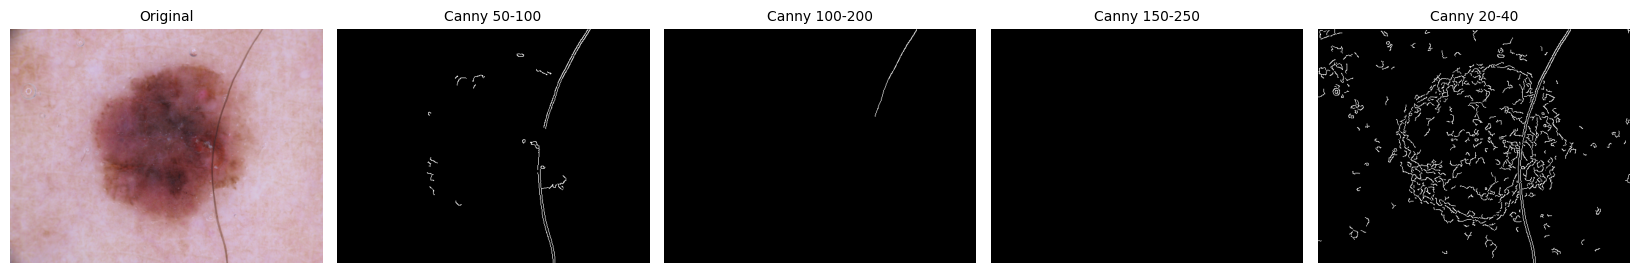

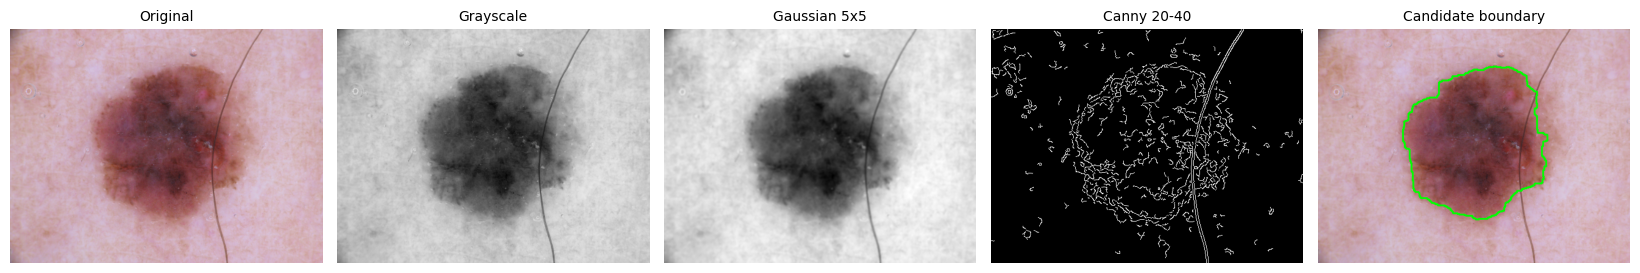

Area: 44208 pixels; Perimeter: 885.91 pixels; Otsu fallback + contour
Image 2: ISIC_0024435.jpg, processed size 512 x 384


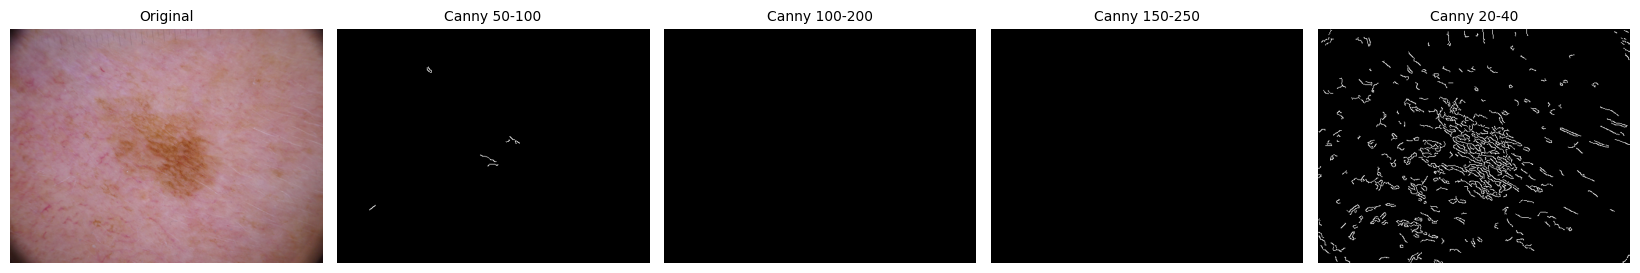

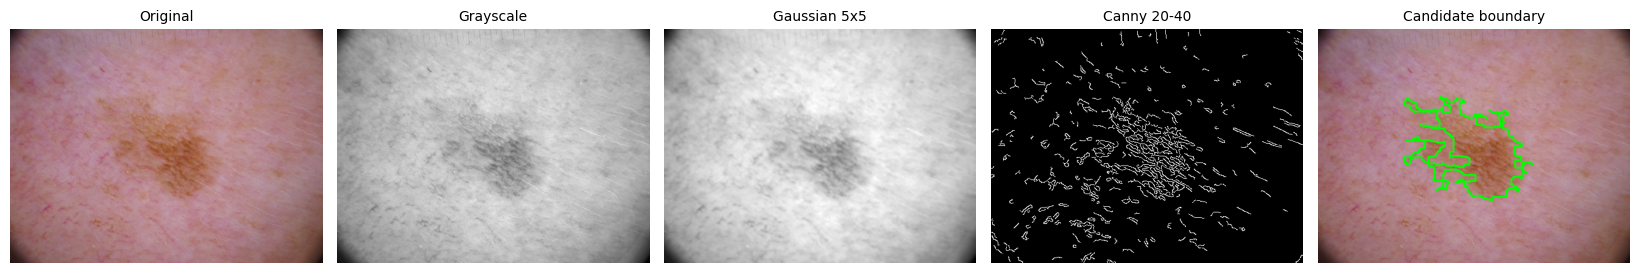

Area: 15304 pixels; Perimeter: 1760.15 pixels; Canny + closing + contour
Image 3: ISIC_0024504.jpg, processed size 512 x 384


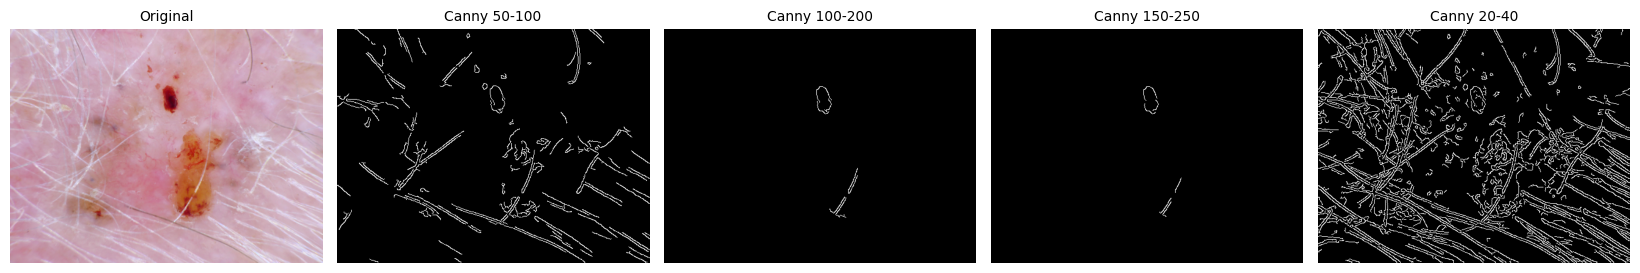

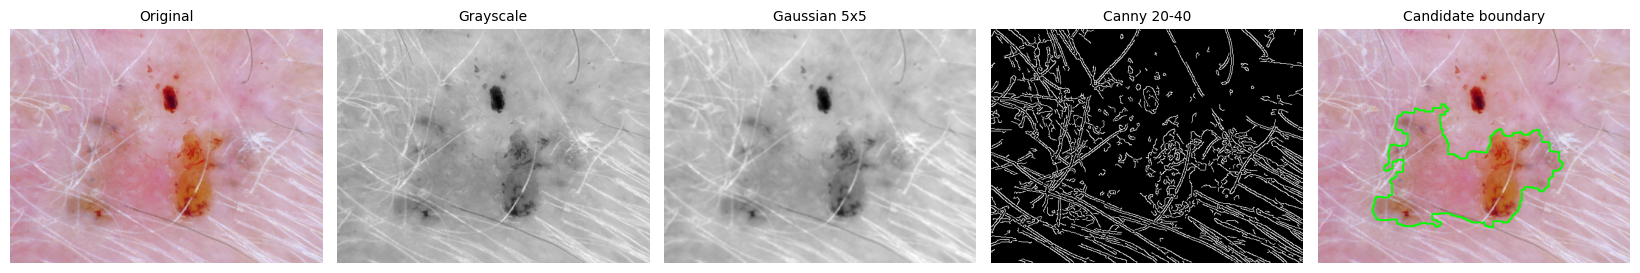

Area: 36459 pixels; Perimeter: 1304.97 pixels; Otsu fallback + contour
Image 4: ISIC_0000019.jpg, processed size 512 x 384


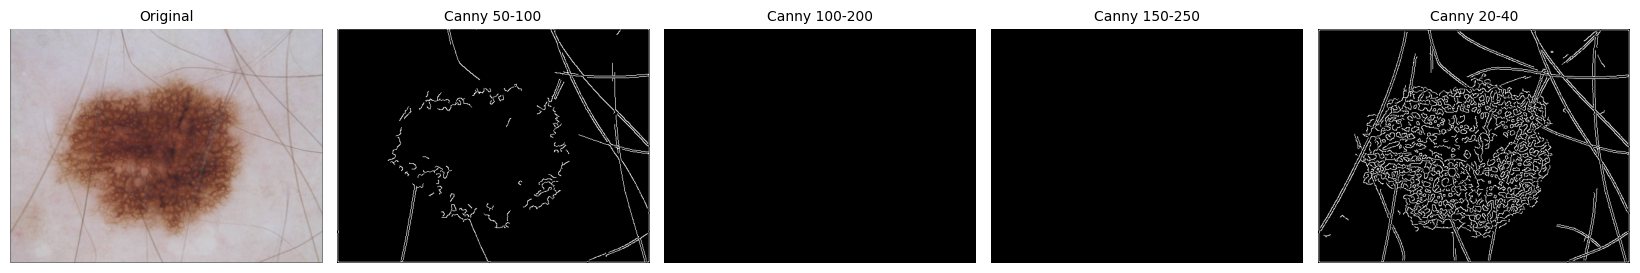

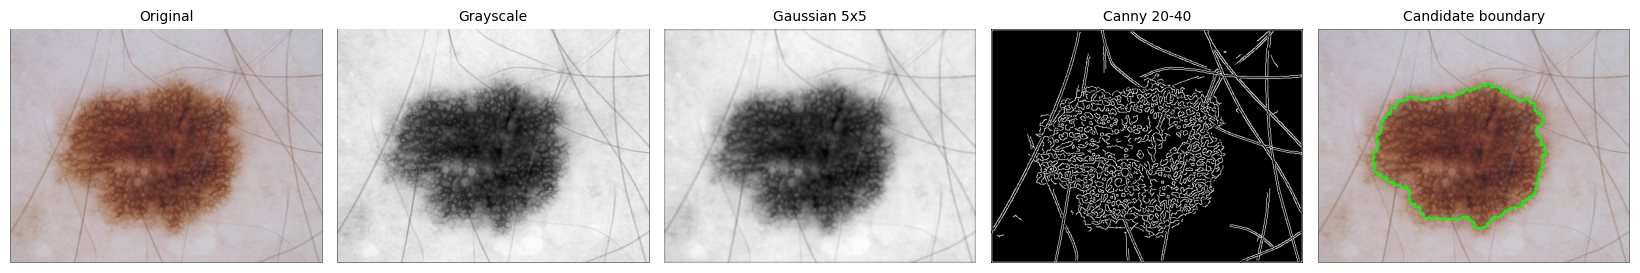

Area: 48467 pixels; Perimeter: 977.67 pixels; Otsu fallback + contour
Image 5: ISIC_0000141.jpg, processed size 512 x 384


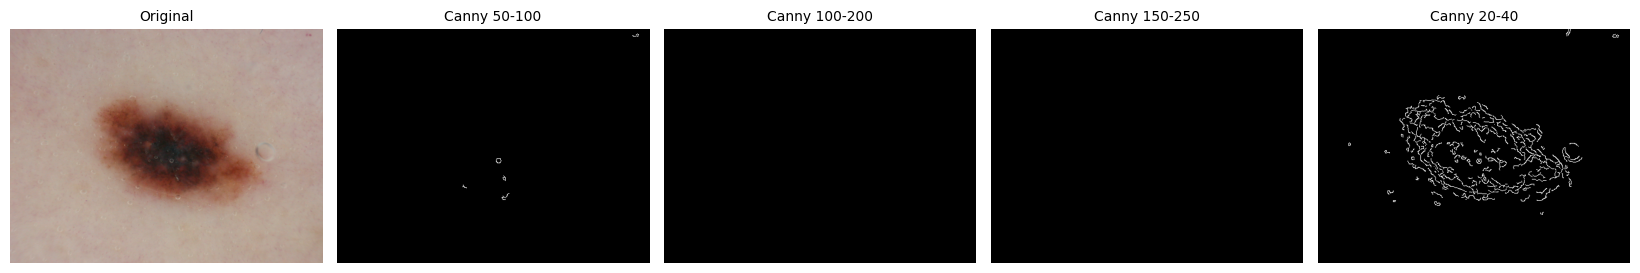

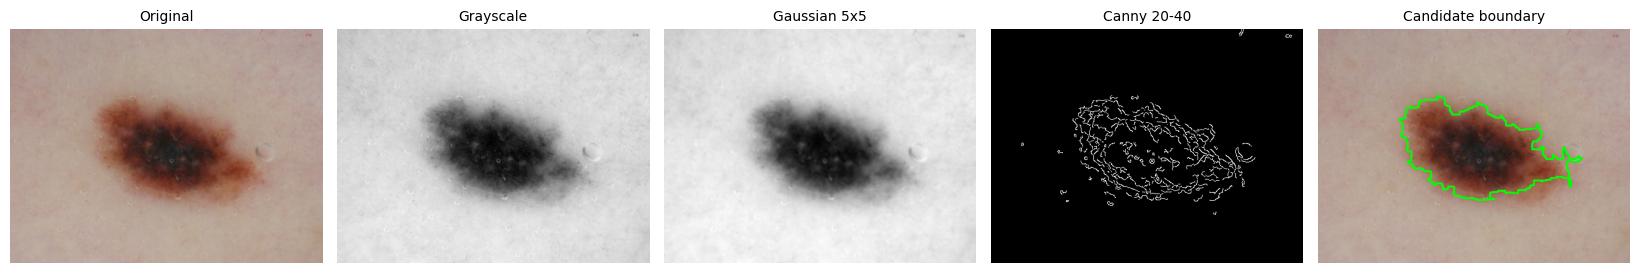

Area: 29172 pixels; Perimeter: 1127.85 pixels; Canny + closing + contour
Required five-image results table:


,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,Gaussian,Canny 20-40,44208,885.91
1,Image 2,Gaussian,Canny 20-40,15304,1760.15
2,Image 3,Gaussian,Canny 20-40,36459,1304.97
3,Image 4,Gaussian,Canny 20-40,48467,977.67
4,Image 5,Gaussian,Canny 20-40,29172,1127.85


Detailed results, including the boundary source:


,Image,Filename,Class,Best Filter,Edge Method,Area (pixels),Perimeter (pixels),Boundary source
0,Image 1,ISIC_0000139.jpg,melanoma,Gaussian,Canny 20-40,44208,885.91,Otsu fallback + contour
1,Image 2,ISIC_0024435.jpg,pigmented benign keratosis,Gaussian,Canny 20-40,15304,1760.15,Canny + closing + contour
2,Image 3,ISIC_0024504.jpg,basal cell carcinoma,Gaussian,Canny 20-40,36459,1304.97,Otsu fallback + contour
3,Image 4,ISIC_0000019.jpg,nevus,Gaussian,Canny 20-40,48467,977.67,Otsu fallback + contour
4,Image 5,ISIC_0000141.jpg,melanoma,Gaussian,Canny 20-40,29172,1127.85,Canny + closing + contour


In [12]:
results = []
processed = []
for index, path in enumerate(paths, start=1):
    # Task 1: load image.
    bgr = cv2.imread(str(path))
    if bgr is None:
        raise ValueError(f"Cannot read image: {path}")
    h, w = bgr.shape[:2]
    scale = min(1, MAX_SIDE / max(h, w))
    bgr = cv2.resize(bgr, (round(w * scale), round(h * scale)), interpolation=cv2.INTER_AREA)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    # Task 2: grayscale and Gaussian filtering.
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    # Task 3: compare thresholds.
    edge_maps = [cv2.Canny(blurred, low, high) for low, high in THRESHOLDS]
    print(f"Image {index}: {path.name}, processed size {gray.shape[1]} x {gray.shape[0]}")
    show_images([rgb] + edge_maps,
                ["Original"] + [f"Canny {low}-{high}" for low, high in THRESHOLDS],
                f"image_{index}_thresholds.png")
    # Task 4: selected after comparing the displayed edge maps.
    chosen = BEST_THRESHOLD
    edges = cv2.Canny(blurred, *chosen)
    # Tasks 5 and 6: contour, filled area and perimeter.
    contour, mask, area, perimeter, method = find_boundary(edges, blurred)
    overlay = rgb.copy()
    if contour is not None:
        cv2.drawContours(overlay, [contour], -1, (0, 255, 0), 2)
    show_images([rgb, gray, blurred, edges, overlay],
                ["Original", "Grayscale", "Gaussian 5x5", f"Canny {chosen[0]}-{chosen[1]}", "Candidate boundary"],
                f"image_{index}_pipeline.png")
    cv2.imwrite(str(OUTPUT_FOLDER / f"image_{index}_mask.png"), mask)
    results.append({"Image": f"Image {index}", "Filename": path.name, "Class": path.parent.name,
                    "Best Filter": BEST_FILTER, "Edge Method": f"Canny {chosen[0]}-{chosen[1]}",
                    "Area (pixels)": area, "Perimeter (pixels)": perimeter,
                    "Boundary source": method})
    processed.append((rgb, gray, blurred, edges, overlay))
    print(f"Area: {area} pixels; Perimeter: {perimeter} pixels; {method}")
results_df = pd.DataFrame(results)
required_columns = ["Image", "Best Filter", "Edge Method", "Area (pixels)", "Perimeter (pixels)"]
print("Required five-image results table:")
display(results_df[required_columns])
print("Detailed results, including the boundary source:")
display(results_df)
results_df.to_csv(OUTPUT_FOLDER / "lesion_results.csv", index=False)

## Final comparison of all eight methods
Every method uses the same grayscale image. Original means no external filter. Average, Gaussian and Median use 5 × 5 kernels. Canny uses 20–40 throughout. Sobel uses normalized gradient magnitude followed by Otsu binarization, so Sobel and Canny do not share numerical thresholds.

The grids below show all eight methods on every input. The completed comparison table records visual observations from these specific images. Noise handling refers to suppression of fine background texture and unwanted edge clutter; no synthetic-noise robustness experiment or expert-mask accuracy test is claimed.

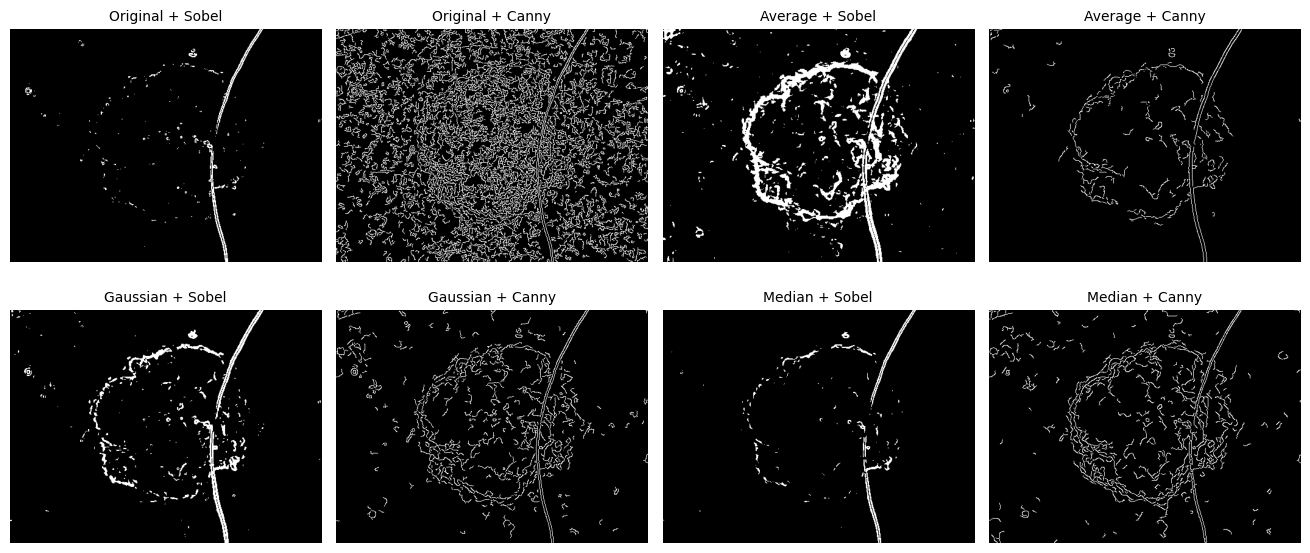

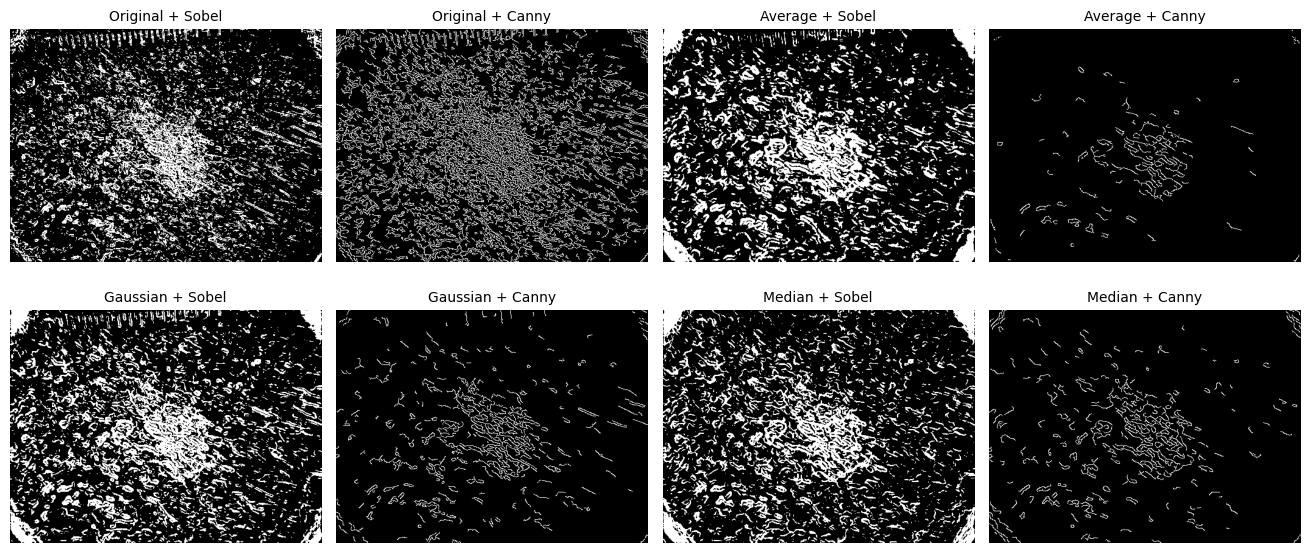

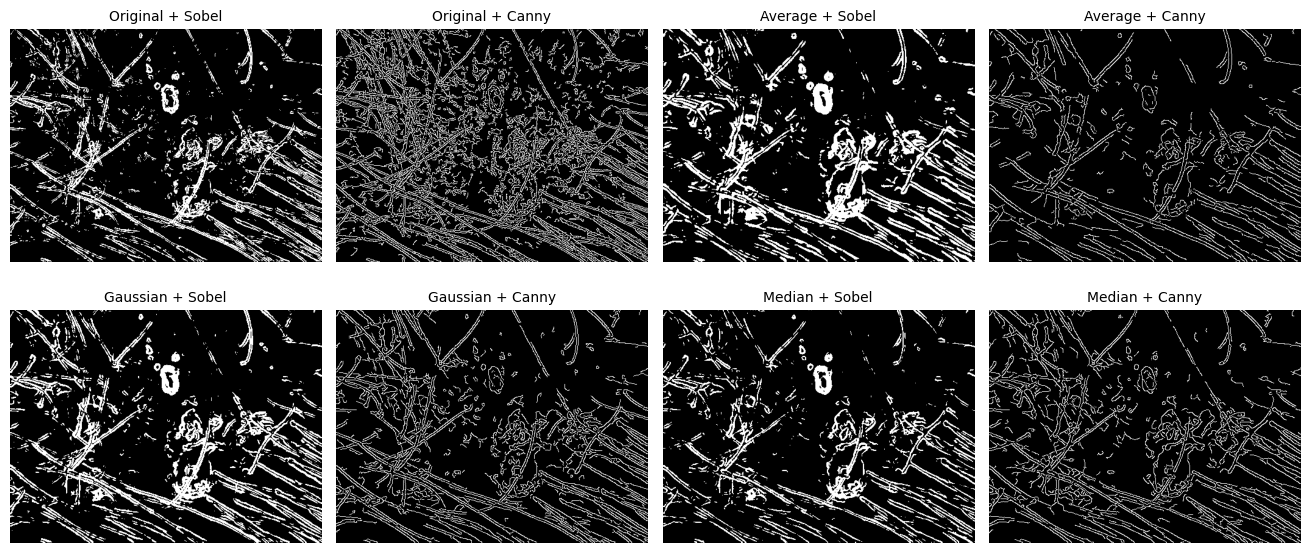

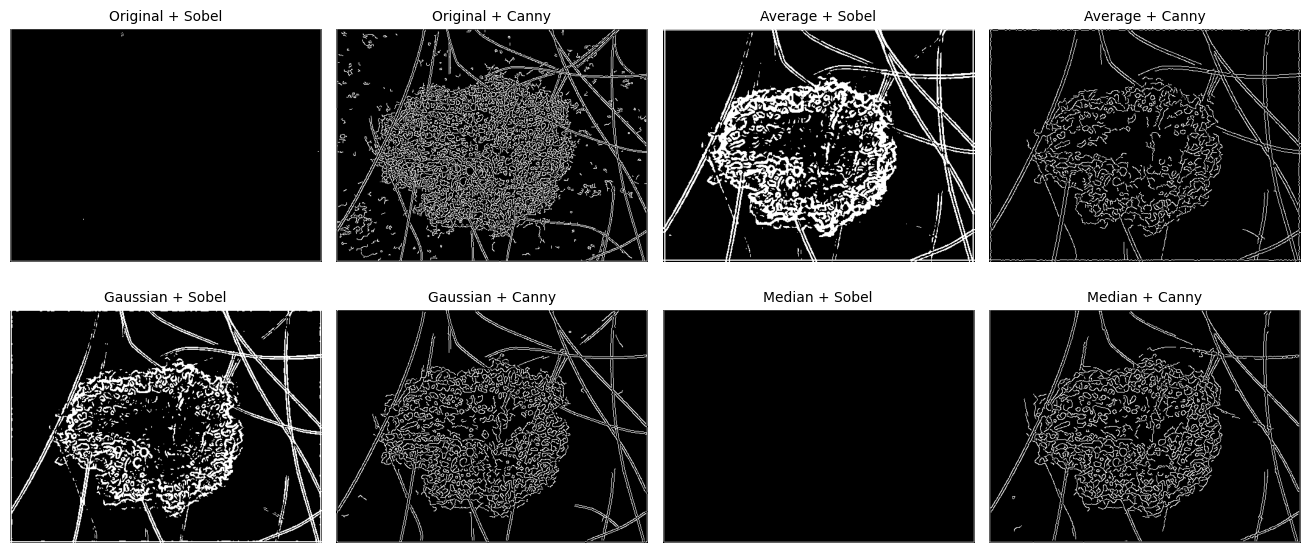

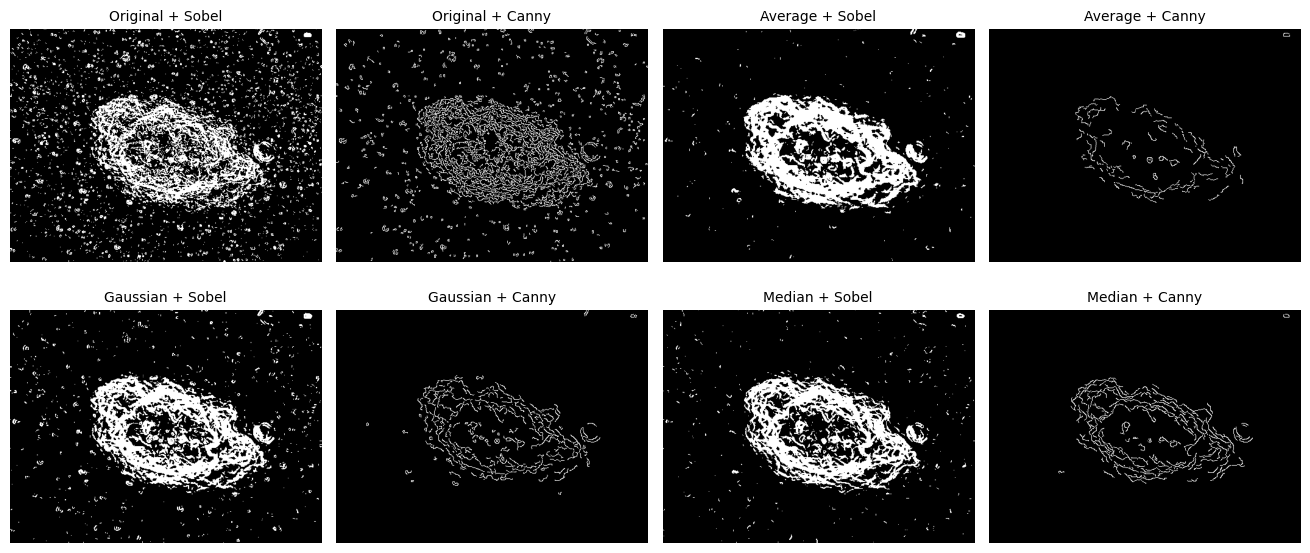

In [13]:
for index, (rgb, gray, blurred, edges, overlay) in enumerate(processed, start=1):
    filters = {"Original": gray, "Average": cv2.blur(gray, (5, 5)),
               "Gaussian": blurred, "Median": cv2.medianBlur(gray, 5)}
    images, titles = [], []
    for name, filtered in filters.items():
        images.extend([sobel_edges(filtered), cv2.Canny(filtered, 20, 40)])
        titles.extend([f"{name} + Sobel", f"{name} + Canny"])
    show_images(images, titles, f"image_{index}_methods.png", columns=4)

In [14]:
comparison_df = pd.DataFrame([['Original + Sobel', 'Weak; texture or strong artifacts dominate', 'Variable: thick responses or very sparse edges', 'Misses weak outlines; almost blank for Image 4', 'Poor overall on these images'], ['Original + Canny', 'Weak; substantial background clutter', 'Thin edges but many unrelated responses', 'Lesion texture, hair and skin edges compete', 'Too cluttered for direct boundary selection'], ['Average + Sobel', 'Reduces fine variation; strong hairs remain', 'Broad gradient bands', 'Shows lesion regions but thick boundaries', 'Moderate; limited precision'], ['Average + Canny', 'Strong reduction of fine texture', 'Thin and sparse; faint details also lost', 'Cleaner maps but several incomplete outlines', 'Useful cleaner alternative'], ['Gaussian + Sobel', 'Reduces texture; retains strong hair', 'Broad or broken responses', 'Some margins visible; hairs remain prominent', 'Moderate'], ['Gaussian + Canny', 'Less clutter than unfiltered Canny', 'Thin; retains more weak detail than averaging', 'Edge contours usable for Images 2 and 5; others need fallback', 'Selected balance; not reliable on all images'], ['Median + Sobel', 'Fine texture reduced; artifacts remain', 'Variable; sparse or almost blank in Image 4', 'Weak margins may disappear after binarization', 'Inconsistent'], ['Median + Canny', 'Less clutter than unfiltered Canny', 'Thin; internal details and hairs remain', 'Reasonable outlines in some images; gaps persist', 'Useful alternative; still needs region processing']],
    columns=["Method", "Noise Handling", "Edge Quality", "Boundary Detection", "Overall Performance"])
display(comparison_df)
comparison_df.to_csv(OUTPUT_FOLDER / "method_comparison.csv", index=False)
print("All figures, masks and both tables are saved in:", OUTPUT_FOLDER.resolve())

,Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
0,Original + Sobel,Weak; texture or strong artifacts dominate,Variable: thick responses or very sparse edges,Misses weak outlines; almost blank for Image 4,Poor overall on these images
1,Original + Canny,Weak; substantial background clutter,Thin edges but many unrelated responses,"Lesion texture, hair and skin edges compete",Too cluttered for direct boundary selection
2,Average + Sobel,Reduces fine variation; strong hairs remain,Broad gradient bands,Shows lesion regions but thick boundaries,Moderate; limited precision
3,Average + Canny,Strong reduction of fine texture,Thin and sparse; faint details also lost,Cleaner maps but several incomplete outlines,Useful cleaner alternative
4,Gaussian + Sobel,Reduces texture; retains strong hair,Broad or broken responses,Some margins visible; hairs remain prominent,Moderate
5,Gaussian + Canny,Less clutter than unfiltered Canny,Thin; retains more weak detail than averaging,Edge contours usable for Images 2 and 5; other...,Selected balance; not reliable on all images
6,Median + Sobel,Fine texture reduced; artifacts remain,Variable; sparse or almost blank in Image 4,Weak margins may disappear after binarization,Inconsistent
7,Median + Canny,Less clutter than unfiltered Canny,Thin; internal details and hairs remain,Reasonable outlines in some images; gaps persist,Useful alternative; still needs region processing


All figures, masks and both tables are saved in: /content/kaggle_lab_outputs


## Task 4 explanation and observations for each image

| Image | Why 20–40 was selected | Boundary result and limitation |
|---|---|---|
| 1 — melanoma | 50–100 retains mainly the prominent hair and a few lesion fragments; higher settings lose almost all lesion detail. 20–40 retains much more of the lesion margin. | Edge contours do not close adequately. Otsu provides a central region; some pale outer pigmentation is omitted. |
| 2 — pigmented benign keratosis | The lesion is faint. 50–100 gives very few fragments; the two higher settings are nearly empty. 20–40 retains its central texture and outline clues. | Closing yields an irregular edge-derived contour. It includes some nearby texture and misses parts of the faint margin; the area and especially the perimeter are rough estimates. |
| 3 — basal cell carcinoma | All settings struggle. 20–40 provides the most lesion-region information, but also many hair edges. 100–200 and 150–250 mainly retain the small dark spot and a few strong lines. | The Otsu fallback includes surrounding skin and misses portions of the visible lesion. This is a **poor boundary estimate**, not successful lesion separation. |
| 4 — nevus | 50–100 gives parts of the outline and strong hairs. The two higher settings lose nearly all edges. 20–40 retains a more complete but textured lesion region. | Otsu isolates the darker central region after edge contour extraction fails. The pale peripheral margin is partly excluded. |
| 5 — melanoma | All three example settings are almost empty. 20–40 reveals the main lesion structure with little distant background clutter. | Closing produces an edge-derived contour; it includes a small extension on the right and omits some faint pigmentation. |

**Best filter interpretation:** Gaussian is selected as the best practical compromise for this five-image lab because it reduces fine texture while preserving weak details. Average + Canny is cleaner in several images but also removes more faint information. This is a qualitative choice for these examples, not a universal or statistically proven ranking.

## Answers to the six questions

**1. Why is Gaussian filtering applied before Canny detection?**  
Gaussian filtering smooths small intensity fluctuations so they are less likely to produce false edges. In these results, filtered Canny maps have much less fine background clutter than unfiltered Canny. Strong hairs remain, and excessive smoothing could erase the faint lesion margin.

**2. How did the three Canny threshold settings affect the result?**  
50–100 retained more edge fragments than 100–200 and 150–250, but it still lost much of the lesion outline. In Images 2, 4 and 5 the higher settings were almost empty. Image 1 retained part of a strong hair at 100–200; Image 3 retained a small dark spot and a few strong lines at high thresholds. Thus fewer edges did not mean a better lesion boundary.

**3. Which threshold produced the best lesion boundary?**  
Among the three example pairs, 50–100 retained the most lesion information, although no pair produced a reliable complete outline for all five images. The additional 20–40 setting was selected because it preserved weak lesion edges that the higher pairs missed. It enabled usable edge-derived candidate contours for Images 2 and 5. Images 1, 3 and 4 required thresholding fallback; Image 3 remained poorly segmented.

**4. Why are edges useful for detecting skin lesions?**  
Edges locate brightness changes between a lesion and nearby skin, providing clues to its outer boundary. However, internal pigmentation, hair and skin texture also produce edges. An edge map must therefore be processed into a candidate region before its area can be measured.

**5. What problems did you observe in detecting the lesion boundary?**  
High thresholds lost faint margins. Low thresholds retained internal texture, skin detail and hairs. Image 1 had a prominent crossing hair, Image 2 had low contrast and a jagged contour, Image 3 had many hairs and an unreliable region estimate, and Image 4 had hairs plus a pale outer rim. Morphological closing sometimes joined unrelated edges, while Otsu often omitted faint pigmentation. Image 5 also showed a small unwanted contour extension.

**6. How could your method be improved?**  
Remove hairs before edge detection, correct uneven illumination and tune thresholds per image. Color-based segmentation could help when lesion and skin have similar grayscale values. Better region-selection rules could reject unwanted structures. Expert segmentation masks would allow objective evaluation using Dice or IoU rather than relying only on visual inspection.

## Conclusion
Filtering followed by Canny is useful for exposing lesion structure, but it does not reliably separate every lesion. Gaussian + Canny at 20–40 retained more useful information than the three higher example settings. Morphology gave candidate contours for two images; three required the labelled Otsu fallback, and the basal-cell image remained poorly segmented. The reported measurements describe the extracted candidate regions and are approximate, particularly for the failed example. No clinical accuracy or diagnostic result is claimed.

## Sources and reproducibility
- Assignment requirements: supplied **Lab Assignment.pdf**.
- Dataset: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic . The tested download was dataset version 1.
- Five fixed filenames and all processing parameters are included above. Only the four requested training classes are used; there is no classifier or train/test evaluation in this boundary-detection lab.
